## Data Loading

In [ ]:
from google.colab import files
import pandas as pd
import io

# Upload the file
uploaded = files.upload()

# Assuming you upload a single CSV file, get its name
file_name = next(iter(uploaded))

# Read the file into a pandas DataFrame
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(f"File '{file_name}' uploaded and loaded successfully. Here are the first 5 rows:")
display(df.head())

Saving batch_corrected_data.csv to batch_corrected_data.csv
File 'batch_corrected_data.csv' uploaded and loaded successfully. Here are the first 5 rows:


,Unnamed: 0,HSBP1,NELL2,NPRL3,TCEB2,EXOSC6,PSMB3,TBCD,SERPINF1,HELZ,...,PRSS2,BTBD9,WWTR1,WFDC10B,POLH,COX5A,GCM1,C15orf57,C15orf40,Label
0,GSM492850,6.534064,6.573029,6.812953,6.258585,6.218720,7.001974,6.496788,6.499871,6.551240,...,6.393795,6.984093,6.762925,7.011454,6.137072,6.839165,5.570427,5.891983,5.859878,Control
1,GSM492851,6.609233,6.310879,6.699519,5.846714,7.392570,6.889221,6.272515,6.738766,6.431379,...,7.064161,6.442589,7.159583,8.594196,5.860549,6.982037,6.040253,5.718513,5.697520,Control
2,GSM492852,6.721986,6.931847,7.227115,6.008232,6.572250,7.342248,5.723225,6.828692,6.600033,...,6.621067,6.804318,6.867309,7.184341,5.784988,6.844805,5.906017,5.786306,6.376775,Control
3,GSM492853,6.707180,7.003938,6.466498,6.192632,5.912111,7.156004,6.462008,6.067499,7.439061,...,5.624766,7.432986,7.419497,6.896438,6.802654,7.488669,5.521953,6.131251,6.103416,Control
4,GSM492854,6.628594,6.584498,7.565656,6.067456,6.767218,7.277817,5.995471,6.548013,6.609580,...,7.004260,6.696453,6.855827,8.128343,5.957011,6.970758,5.437434,5.710537,6.176312,Control


## Differential Gene Expression Analysis

In [ ]:
from scipy import stats
import numpy as np

# Assuming the 'Label' column exists and separates two groups
# Replace 'Label' with your actual group column name if different.
# Replace 'Control' and 'Disease' with your actual group names.

group1_name = df['Label'].unique()[0]
group2_name = df['Label'].unique()[1]

group1_data = df[df['Label'] == group1_name].drop(columns=['Label', 'Unnamed: 0'])
group2_data = df[df['Label'] == group2_name].drop(columns=['Label', 'Unnamed: 0'])

deg_results = []
for gene in df.drop(columns=['Label', 'Unnamed: 0']).columns:
    # Perform independent t-test for each gene
    t_stat, p_val = stats.ttest_ind(group1_data[gene], group2_data[gene], equal_var=False) # Welch's t-test
    deg_results.append({'Gene': gene, 'T_Statistic': t_stat, 'P_Value': p_val})

deg_df = pd.DataFrame(deg_results)

# Adjust p-values for multiple testing (e.g., Benjamini-Hochberg correction)
from statsmodels.stats.multitest import multipletests
deg_df['Adjusted_P_Value'] = multipletests(deg_df['P_Value'], method='fdr_bh')[1]

# Sort by adjusted p-value and then by absolute T-statistic
deg_df = deg_df.sort_values(by=['Adjusted_P_Value', 'T_Statistic'], ascending=[True, False])

print("Differential Expression Analysis Results:")
display(deg_df.head())

Differential Expression Analysis Results:


,Gene,T_Statistic,P_Value,Adjusted_P_Value
3023,CABIN1,3.641533,0.000320,0.530158
2338,FCN2,3.408982,0.000743,0.530158
218,ADK,3.252023,0.001289,0.530158
224,GTPBP6,3.103374,0.002094,0.530158
178,CD86,3.085880,0.002228,0.530158


In [ ]:
top_10_degs = deg_df.head(10)['Gene'].tolist()

print(f"Top 10 Differentially Expressed Genes: {top_10_degs}")

# Create a new DataFrame with only the top 10 DEGs and the 'Label' column
df_top_degs = df[top_10_degs + ['Label']].copy()

Top 10 Differentially Expressed Genes: ['CABIN1', 'FCN2', 'ADK', 'GTPBP6', 'CD86', 'NDRG1', 'PMP22', 'PPP6C', 'DR1', 'GYG1']


## Feature Selection

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Prepare data for modeling
X = df_top_degs[top_10_degs] # Features are the top 10 DEGs

# Encode the 'Label' column into numerical labels
le = LabelEncoder()
y = le.fit_transform(df_top_degs['Label']) # Target variable

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Perform LASSO with cross-validation to find the optimal alpha
lasso = LassoCV(cv=5, random_state=42).fit(X_train, y_train)

# Get the coefficients
lasso_coefficients = pd.Series(lasso.coef_, index=X_train.columns)

# Select features with non-zero coefficients
selected_features_lasso = lasso_coefficients[lasso_coefficients != 0].index.tolist()

print("LASSO Selected Features (Non-zero coefficients):")
print(selected_features_lasso)
print(f"Optimal alpha found by LassoCV: {lasso.alpha_}")

# Filter X_train and X_test to include only selected LASSO features
X_train_lasso = X_train[selected_features_lasso]
X_test_lasso = X_test[selected_features_lasso]

LASSO Selected Features (Non-zero coefficients):
['CABIN1', 'FCN2', 'ADK', 'GTPBP6', 'CD86', 'NDRG1', 'PMP22', 'PPP6C', 'DR1', 'GYG1']
Optimal alpha found by LassoCV: 0.0015092596293251413


## Predictive Modeling

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# --- Logistic Regression ---
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' for small datasets
log_reg_model.fit(X_train_lasso, y_train)

y_pred_lr = log_reg_model.predict(X_test_lasso)
y_proba_lr = log_reg_model.predict_proba(X_test_lasso)[:, 1] # Probability of the positive class

print("\n--- Logistic Regression Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

# --- Support Vector Machine (SVM) ---
# Using a linear kernel for better interpretability and faster training on smaller feature sets
svm_model = SVC(kernel='linear', random_state=42, probability=True)
svm_model.fit(X_train_lasso, y_train)

y_pred_svm = svm_model.predict(X_test_lasso)
y_proba_svm = svm_model.predict_proba(X_test_lasso)[:, 1]

print("\n--- Support Vector Machine (SVM) Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))


--- Logistic Regression Results ---
Accuracy: 0.7857
Classification Report:
              precision    recall  f1-score   support

     Control       0.75      0.69      0.72        39
         MDD       0.81      0.85      0.83        59

    accuracy                           0.79        98
   macro avg       0.78      0.77      0.77        98
weighted avg       0.78      0.79      0.78        98


--- Support Vector Machine (SVM) Results ---
Accuracy: 0.6735
Classification Report:
              precision    recall  f1-score   support

     Control       0.58      0.67      0.62        39
         MDD       0.75      0.68      0.71        59

    accuracy                           0.67        98
   macro avg       0.67      0.67      0.67        98
weighted avg       0.68      0.67      0.68        98



## LASSO Coefficents for Slected genes

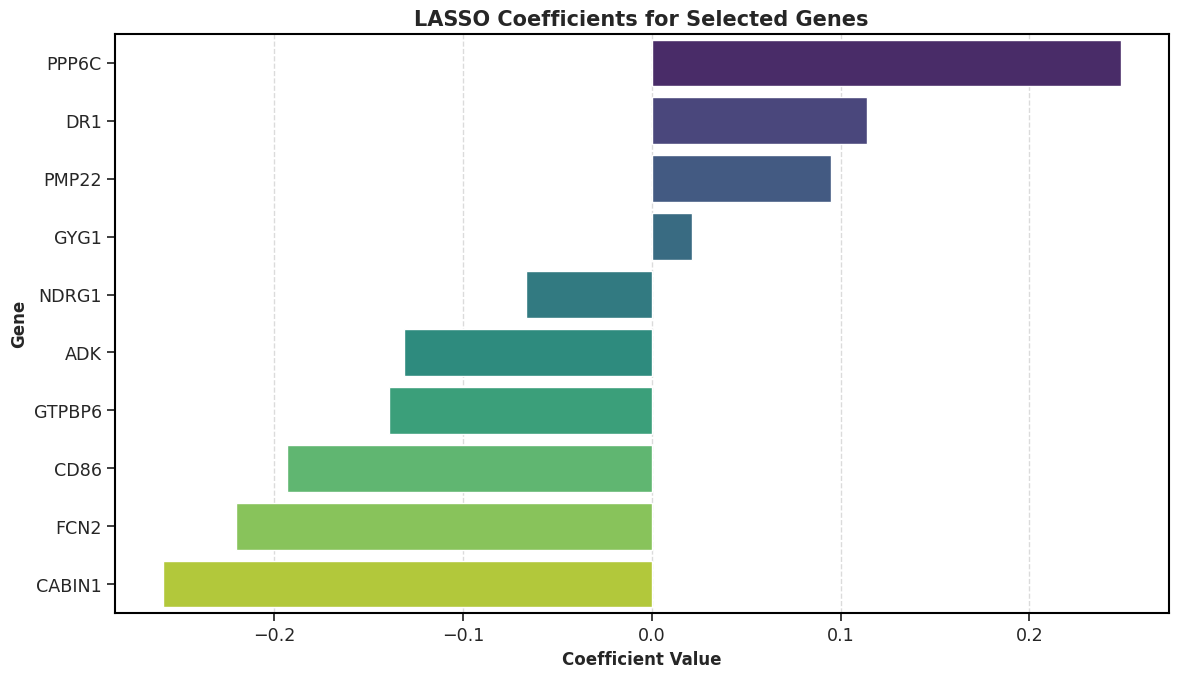

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for easier plotting
lasso_coef_df = pd.DataFrame({
    'Feature': lasso_coefficients.index,
    'Coefficient': lasso_coefficients.values
})

# Sort for better visualization
lasso_coef_df = lasso_coef_df.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Coefficient', y='Feature', hue='Feature', data=lasso_coef_df, palette='viridis', legend=False) # Add hue and set legend=False to address FutureWarning
plt.title('LASSO Coefficients for Selected Genes', fontsize=15, fontweight='bold') # Consistent title font size
plt.xlabel('Coefficient Value', fontsize=12, fontweight='bold') # Consistent label font size
plt.ylabel('Gene', fontsize=12, fontweight='bold') # Consistent label font size
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Black border around plot
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('black')

plt.tight_layout()
plt.show()

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# --- Random Forest ---
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_lasso, y_train)

y_pred_rf = rf_model.predict(X_test_lasso)
y_proba_rf = rf_model.predict_proba(X_test_lasso)[:, 1] # Probability of the positive class

print("\n--- Random Forest Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))


--- Random Forest Results ---
Accuracy: 0.6633
Classification Report:
              precision    recall  f1-score   support

     Control       0.57      0.59      0.58        39
         MDD       0.72      0.71      0.72        59

    accuracy                           0.66        98
   macro avg       0.65      0.65      0.65        98
weighted avg       0.66      0.66      0.66        98



## ANN

In [ ]:
from sklearn.neural_network import MLPClassifier

# --- Artificial Neural Network (ANN) - Multi-layer Perceptron ---
# Using default parameters for simplicity, but these can be tuned
mlp_model = MLPClassifier(random_state=42, max_iter=1000) # Increased max_iter for convergence
mlp_model.fit(X_train_lasso, y_train)

y_pred_mlp = mlp_model.predict(X_test_lasso)
y_proba_mlp = mlp_model.predict_proba(X_test_lasso)[:, 1] # Probability of the positive class

print("\n--- ANN (MLPClassifier) Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_mlp):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))


--- ANN (MLPClassifier) Results ---
Accuracy: 0.6122
Classification Report:
              precision    recall  f1-score   support

     Control       1.00      0.03      0.05        39
         MDD       0.61      1.00      0.76        59

    accuracy                           0.61        98
   macro avg       0.80      0.51      0.40        98
weighted avg       0.76      0.61      0.48        98



## LDA

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# --- Linear Discriminant Analysis (LDA) ---
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train_lasso, y_train)

y_pred_lda = lda_model.predict(X_test_lasso)
y_proba_lda = lda_model.predict_proba(X_test_lasso)[:, 1] # Probability of the positive class

print("\n--- LDA Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lda):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lda, target_names=le.classes_))


--- LDA Results ---
Accuracy: 0.6735
Classification Report:
              precision    recall  f1-score   support

     Control       0.58      0.67      0.62        39
         MDD       0.75      0.68      0.71        59

    accuracy                           0.67        98
   macro avg       0.67      0.67      0.67        98
weighted avg       0.68      0.67      0.68        98



## XG Boost


In [ ]:
from xgboost import XGBClassifier

# --- XGBoost Classifier ---
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss') # Suppress warning
xgb_model.fit(X_train_lasso, y_train)

y_pred_xgb = xgb_model.predict(X_test_lasso)
y_proba_xgb = xgb_model.predict_proba(X_test_lasso)[:, 1] # Probability of the positive class

print("\n--- XGBoost Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))


--- XGBoost Results ---
Accuracy: 0.6633
Classification Report:
              precision    recall  f1-score   support

     Control       0.57      0.62      0.59        39
         MDD       0.73      0.69      0.71        59

    accuracy                           0.66        98
   macro avg       0.65      0.66      0.65        98
weighted avg       0.67      0.66      0.67        98



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:41:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Performance Evaluation Metrics and Visualizations

ROC-AUC Curve

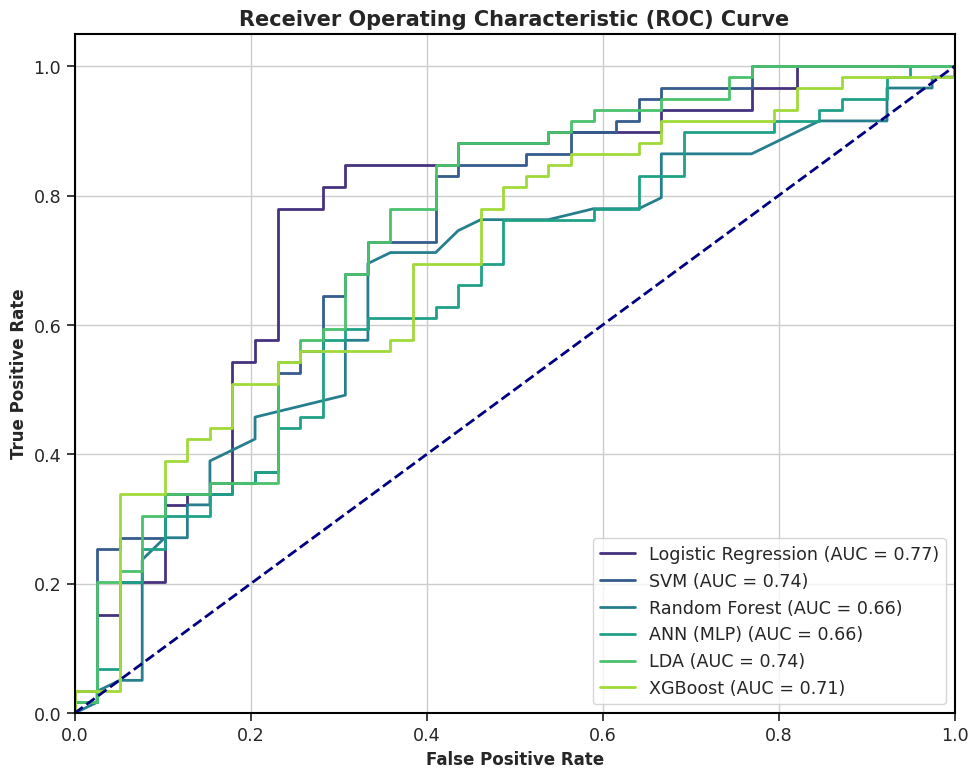


ROC-AUC for Logistic Regression: 0.7692
ROC-AUC for SVM: 0.7384
ROC-AUC for Random Forest: 0.6619
ROC-AUC for ANN (MLP): 0.6567
ROC-AUC for LDA: 0.7432
ROC-AUC for XGBoost: 0.7066


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# Get a color palette for the ROC curves
models_list = ['Logistic Regression', 'SVM', 'Random Forest', 'ANN (MLP)', 'LDA', 'XGBoost']
palette = sns.color_palette('viridis', n_colors=len(models_list))

# ROC for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test_for_metrics, y_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, color=palette[0], lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')

# ROC for SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test_for_metrics, y_proba_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)
plt.plot(fpr_svm, tpr_svm, color=palette[1], lw=2, label=f'SVM (AUC = {roc_auc_svm:.2f})')

# ROC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test_for_metrics, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, color=palette[2], lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

# ROC for ANN (MLPClassifier)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test_for_metrics, y_proba_mlp)
roc_auc_mlp = auc(fpr_mlp, tpr_mlp)
plt.plot(fpr_mlp, tpr_mlp, color=palette[3], lw=2, label=f'ANN (MLP) (AUC = {roc_auc_mlp:.2f})')

# ROC for LDA
fpr_lda, tpr_lda, _ = roc_curve(y_test_for_metrics, y_proba_lda)
roc_auc_lda = auc(fpr_lda, tpr_lda)
plt.plot(fpr_lda, tpr_lda, color=palette[4], lw=2, label=f'LDA (AUC = {roc_auc_lda:.2f})')

# ROC for XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_for_metrics, y_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, color=palette[5], lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold') # Consistent label font size
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold') # Consistent label font size
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=15, fontweight='bold') # Consistent title font size
plt.legend(loc="lower right")
plt.grid(True)

# Black border around plot
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('black')

plt.tight_layout()
plt.show()

print(f"\nROC-AUC for Logistic Regression: {roc_auc_lr:.4f}")
print(f"ROC-AUC for SVM: {roc_auc_svm:.4f}")
print(f"ROC-AUC for Random Forest: {roc_auc_rf:.4f}")
print(f"ROC-AUC for ANN (MLP): {roc_auc_mlp:.4f}")
print(f"ROC-AUC for LDA: {roc_auc_lda:.4f}")
print(f"ROC-AUC for XGBoost: {roc_auc_xgb:.4f}")

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Re-initialize the LabelEncoder and apply it to the full dataset 'y'
le = LabelEncoder()
y_full = le.fit_transform(df_top_degs['Label'])

# Get the full feature set (LASSO selected features) from the original df_top_degs
# In this case, 'selected_features_lasso' are all 'top_10_degs'
X_full_lasso = df_top_degs[selected_features_lasso]

# Define the cross-validation strategy
# StratifiedKFold ensures that each fold has approximately the same percentage of samples of each target class
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n--- Cross-Validation Results (AUC) ---")

# --- Logistic Regression Cross-Validation ---
log_reg_model_cv = LogisticRegression(random_state=42, solver='liblinear')
scores_lr_auc = cross_val_score(log_reg_model_cv, X_full_lasso, y_full, cv=skf, scoring='roc_auc')
print(f"Logistic Regression CV AUC: {scores_lr_auc.mean():.4f} (+/- {scores_lr_auc.std() * 2:.4f})")

# --- SVM Cross-Validation ---
svm_model_cv = SVC(kernel='linear', random_state=42, probability=True)
scores_svm_auc = cross_val_score(svm_model_cv, X_full_lasso, y_full, cv=skf, scoring='roc_auc')
print(f"SVM CV AUC: {scores_svm_auc.mean():.4f} (+/- {scores_svm_auc.std() * 2:.4f})")

# --- Random Forest Cross-Validation ---
rf_model_cv = RandomForestClassifier(random_state=42)
scores_rf_auc = cross_val_score(rf_model_cv, X_full_lasso, y_full, cv=skf, scoring='roc_auc')
print(f"Random Forest CV AUC: {scores_rf_auc.mean():.4f} (+/- {scores_rf_auc.std() * 2:.4f})")

# --- ANN (MLPClassifier) Cross-Validation ---
mlp_model_cv = MLPClassifier(random_state=42, max_iter=1000)
scores_mlp_auc = cross_val_score(mlp_model_cv, X_full_lasso, y_full, cv=skf, scoring='roc_auc')
print(f"ANN (MLP) CV AUC: {scores_mlp_auc.mean():.4f} (+/- {scores_mlp_auc.std() * 2:.4f})")

# --- LDA Cross-Validation ---
lda_model_cv = LinearDiscriminantAnalysis()
scores_lda_auc = cross_val_score(lda_model_cv, X_full_lasso, y_full, cv=skf, scoring='roc_auc')
print(f"LDA CV AUC: {scores_lda_auc.mean():.4f} (+/- {scores_lda_auc.std() * 2:.4f})")

# --- XGBoost Cross-Validation ---
xgb_model_cv = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
scores_xgb_auc = cross_val_score(xgb_model_cv, X_full_lasso, y_full, cv=skf, scoring='roc_auc')
print(f"XGBoost CV AUC: {scores_xgb_auc.mean():.4f} (+/- {scores_xgb_auc.std() * 2:.4f})")


--- Cross-Validation Results (AUC) ---
Logistic Regression CV AUC: 0.7341 (+/- 0.1607)
SVM CV AUC: 0.7255 (+/- 0.1481)
Random Forest CV AUC: 0.7336 (+/- 0.1128)
ANN (MLP) CV AUC: 0.7266 (+/- 0.1761)
LDA CV AUC: 0.7366 (+/- 0.1315)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:41:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:41:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:41:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:41:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost CV AUC: 0.7504 (+/- 0.1079)


## K-Cross Validation

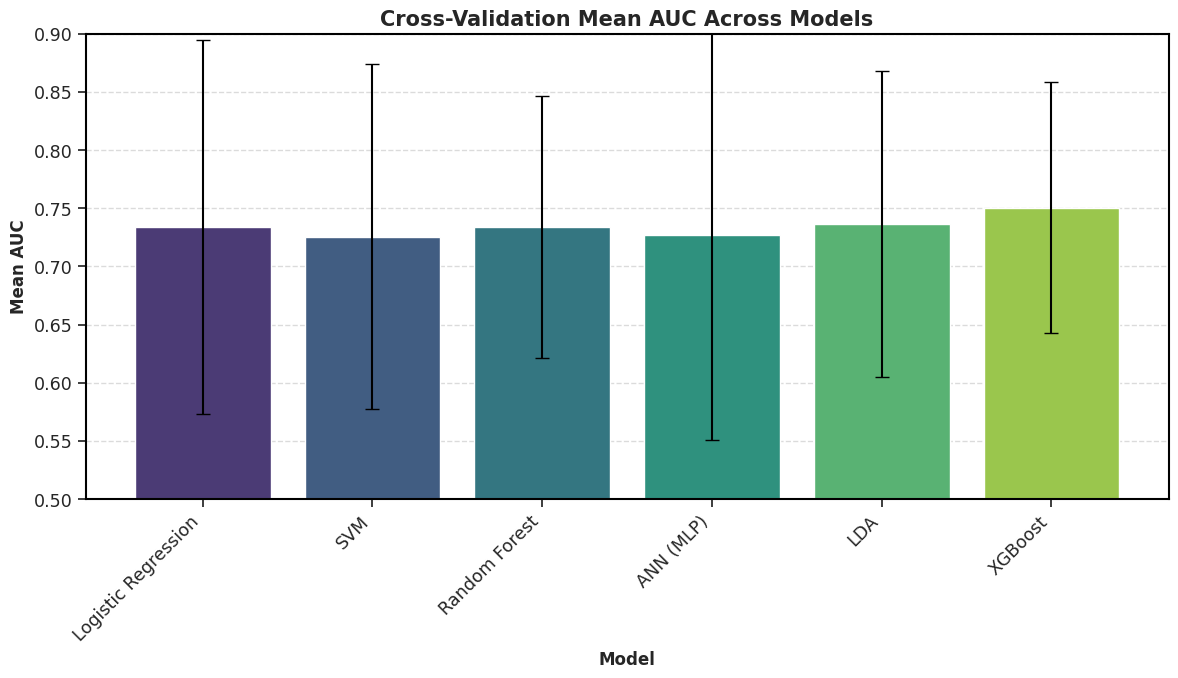

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Collecting mean and std of cross-validation scores for AUC
cv_results_auc = {
    'Model': ['Logistic Regression', 'SVM', 'Random Forest', 'ANN (MLP)', 'LDA', 'XGBoost'],
    'Mean AUC': [scores_lr_auc.mean(), scores_svm_auc.mean(), scores_rf_auc.mean(), scores_mlp_auc.mean(), scores_lda_auc.mean(), scores_xgb_auc.mean()],
    'Std AUC': [scores_lr_auc.std(), scores_svm_auc.std(), scores_rf_auc.std(), scores_mlp_auc.std(), scores_lda_auc.std(), scores_xgb_auc.std()]
}

cv_df_auc = pd.DataFrame(cv_results_auc);

plt.figure(figsize=(12, 7))

# Plot the bars using seaborn without error bars
ax = sns.barplot(x='Model', y='Mean AUC', hue='Model', data=cv_df_auc, palette='viridis', legend=False)

# Manually add error bars using matplotlib's errorbar function
# Get x-positions for the error bars (center of each bar)
bar_x_positions = [patch.get_x() + patch.get_width() / 2 for patch in ax.patches]

plt.errorbar(
    x=bar_x_positions,
    y=cv_df_auc['Mean AUC'],
    yerr=cv_df_auc['Std AUC'] * 2, # yerr for 2 standard deviations
    fmt='none', # No line connecting error points
    c='black',  # Color of the error bars
    capsize=5   # Size of the error bar caps
)

plt.title('Cross-Validation Mean AUC Across Models', fontsize=15, fontweight='bold') # Consistent title font size
plt.xlabel('Model', fontsize=12, fontweight='bold') # Consistent label font size
plt.ylabel('Mean AUC', fontsize=12, fontweight='bold') # Consistent label font size
plt.ylim(0.5, 0.9) # Adjust y-axis limit for better comparison for AUC values
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')

# Black border around plot
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('black')

plt.tight_layout()
plt.show()

## Biomarker Gene Insights

In [ ]:
print("Potential Biomarker Genes (Selected by LASSO and used in models):")
if selected_features_lasso:
    print(selected_features_lasso)
else:
    print("No genes were selected by LASSO. This might happen if the optimal alpha makes all coefficients zero or if the genes are not strongly predictive after initial selection.")

print("\nThese genes were chosen because they were among the top differentially expressed genes and were also identified by LASSO regression as important features for distinguishing between the groups in the predictive models (Logistic Regression/SVM).")

Potential Biomarker Genes (Selected by LASSO and used in models):
['CABIN1', 'FCN2', 'ADK', 'GTPBP6', 'CD86', 'NDRG1', 'PMP22', 'PPP6C', 'DR1', 'GYG1']

These genes were chosen because they were among the top differentially expressed genes and were also identified by LASSO regression as important features for distinguishing between the groups in the predictive models (Logistic Regression/SVM).


Expression Ranges

In [ ]:
print("\nExpression Value Ranges for Biomarker Genes:")

for gene in selected_features_lasso:
    control_min = df_top_degs[df_top_degs['Label'] == 'Control'][gene].min()
    control_max = df_top_degs[df_top_degs['Label'] == 'Control'][gene].max()
    mdd_min = df_top_degs[df_top_degs['Label'] == 'MDD'][gene].min()
    mdd_max = df_top_degs[df_top_degs['Label'] == 'MDD'][gene].max()

    print(f"\nGene: {gene}")
    print(f"  Control Group: Min = {control_min:.2f}, Max = {control_max:.2f}")
    print(f"  MDD Group:     Min = {mdd_min:.2f}, Max = {mdd_max:.2f}")


Expression Value Ranges for Biomarker Genes:

Gene: CABIN1
  Control Group: Min = 5.60, Max = 7.58
  MDD Group:     Min = 5.35, Max = 7.65

Gene: FCN2
  Control Group: Min = 6.11, Max = 8.20
  MDD Group:     Min = 5.62, Max = 8.50

Gene: ADK
  Control Group: Min = 5.46, Max = 7.14
  MDD Group:     Min = 5.19, Max = 7.31

Gene: GTPBP6
  Control Group: Min = 6.80, Max = 8.54
  MDD Group:     Min = 6.51, Max = 8.88

Gene: CD86
  Control Group: Min = 5.51, Max = 7.13
  MDD Group:     Min = 5.09, Max = 7.11

Gene: NDRG1
  Control Group: Min = 6.45, Max = 8.88
  MDD Group:     Min = 6.40, Max = 9.09

Gene: PMP22
  Control Group: Min = 5.02, Max = 6.51
  MDD Group:     Min = 5.18, Max = 7.13

Gene: PPP6C
  Control Group: Min = 5.27, Max = 7.61
  MDD Group:     Min = 5.75, Max = 7.96

Gene: DR1
  Control Group: Min = 5.30, Max = 6.93
  MDD Group:     Min = 5.29, Max = 7.35

Gene: GYG1
  Control Group: Min = 4.97, Max = 7.26
  MDD Group:     Min = 5.42, Max = 7.78


## Confusion Matrices


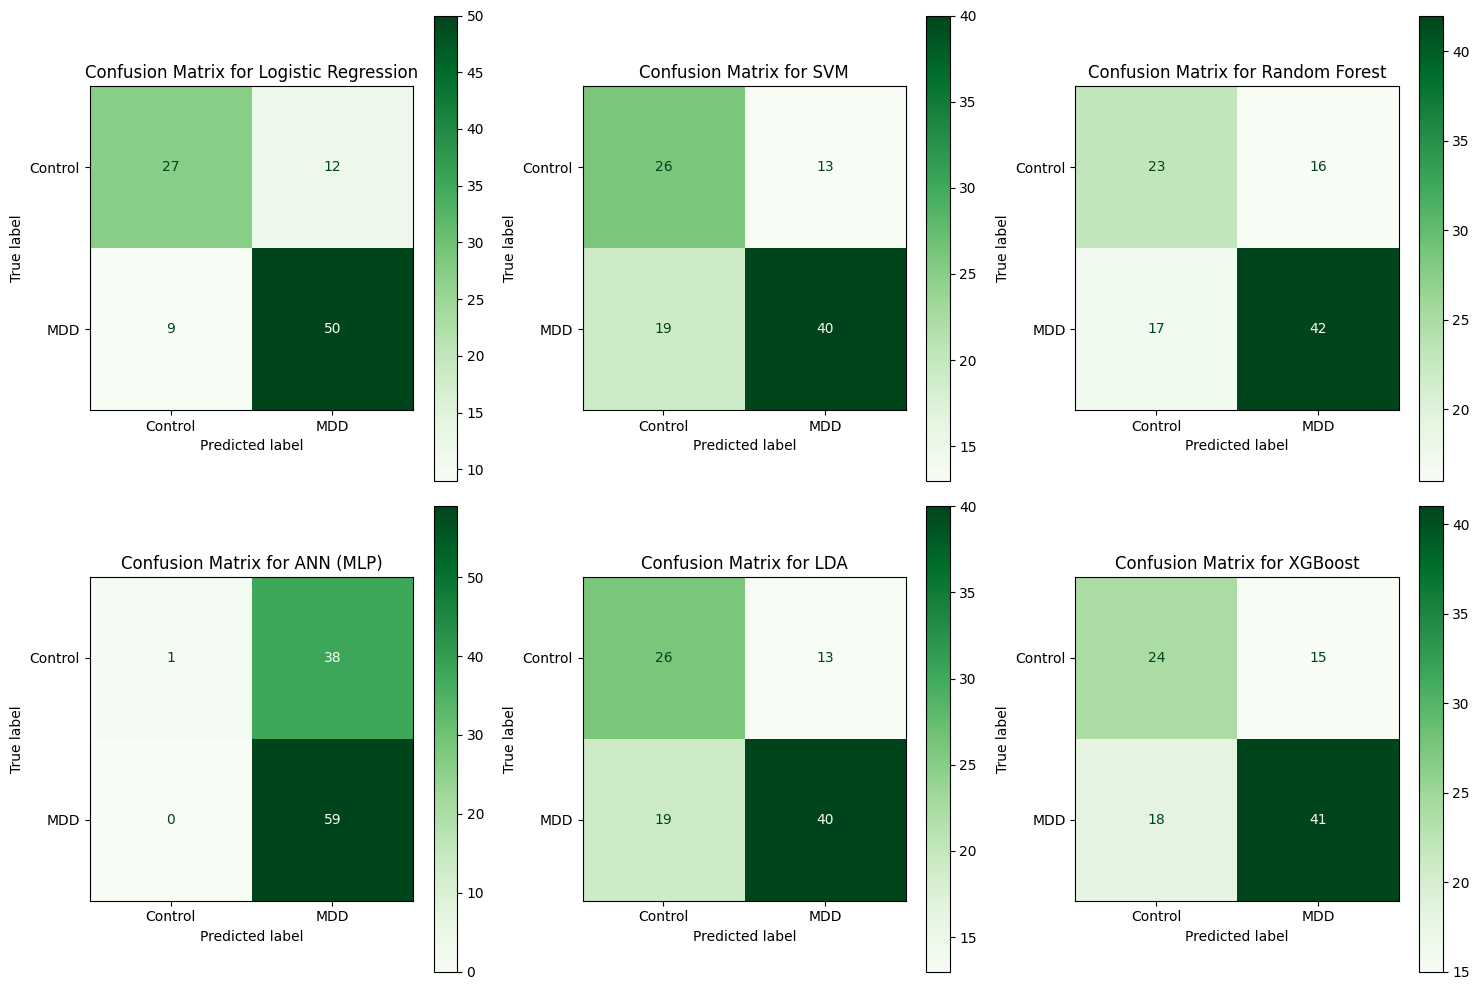

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Get class names from LabelEncoder
class_names = le.classes_

models = {
    'Logistic Regression': log_reg_model,
    'SVM': svm_model,
    'Random Forest': rf_model,
    'ANN (MLP)': mlp_model,
    'LDA': lda_model,
    'XGBoost': xgb_model
}

predictions = {
    'Logistic Regression': y_pred_lr,
    'SVM': y_pred_svm,
    'Random Forest': y_pred_rf,
    'ANN (MLP)': y_pred_mlp,
    'LDA': y_pred_lda,
    'XGBoost': y_pred_xgb
}

plt.figure(figsize=(15, 10))
for i, (name, model) in enumerate(models.items()):
    cm = confusion_matrix(y_test_for_metrics, predictions[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    plt.subplot(2, 3, i + 1) # 2 rows, 3 columns
    disp.plot(cmap='Greens', ax=plt.gca()) # Use 'Greens' colormap for a softer look
    plt.title(f'Confusion Matrix for {name}')

plt.tight_layout()
plt.show()

## Model Deployment

Logistic Regression Model Saved for Deployment

In [ ]:
import joblib
from google.colab import files

# Define the filename for your model
model_filename = 'logistic_regression_model.joblib'

# Save the Logistic Regression model
joblib.dump(log_reg_model, model_filename)

print(f"Logistic Regression model saved to '{model_filename}'.")

# Provide a link to download the model file
files.download(model_filename)

Logistic Regression model saved to 'logistic_regression_model.joblib'.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## K-Fold Cross-Validation

In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Assuming X and y are already defined from previous cells (e.g., X_full_lasso, y_full)
# For demonstration, let's create dummy data if they are not available
if 'X_full_lasso' not in locals() or 'y_full' not in locals():
    print("Using dummy data for cross-validation demonstration.")
    from sklearn.datasets import make_classification
    X, y = make_classification(n_samples=200, n_features=10, n_classes=2, random_state=42)
else:
    X = X_full_lasso
    y = y_full

# 1. Initialize the model
model = LogisticRegression(random_state=42, solver='liblinear')

# 2. Define the K-Fold Cross-Validation splitter
kf = KFold(n_splits=5, shuffle=True, random_state=42) # 5 folds, shuffled

# To store scores from each fold
accuracy_scores = []

print(f"Performing {kf.get_n_splits()} fold cross-validation...")

# 3. Iterate through each fold
for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    X_train, X_test = X.iloc[train_index] if isinstance(X, pd.DataFrame) else X[train_index], \
                      X.iloc[test_index] if isinstance(X, pd.DataFrame) else X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Evaluate the model
    acc = accuracy_score(y_test, y_pred)
    accuracy_scores.append(acc)
    print(f"  Fold {fold+1} Accuracy: {acc:.4f}")

# 4. Aggregate results
print(f"\nAverage Cross-Validation Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Standard Deviation of Cross-Validation Accuracy: {np.std(accuracy_scores):.4f}")


Performing 5 fold cross-validation...
  Fold 1 Accuracy: 0.7692
  Fold 2 Accuracy: 0.6615
  Fold 3 Accuracy: 0.7846
  Fold 4 Accuracy: 0.6000
  Fold 5 Accuracy: 0.6719

Average Cross-Validation Accuracy: 0.6975
Standard Deviation of Cross-Validation Accuracy: 0.0696


R2_score, Mean Squared Error, Mean Absolute Error

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Re-establishing y_test specific for metrics to avoid conflicts and ensure correct length
X_for_metrics_split = df_top_degs[top_10_degs]
le_for_metrics_split = LabelEncoder()
y_for_metrics_split = le_for_metrics_split.fit_transform(df_top_degs['Label'])
_, _, _, y_test_for_metrics = train_test_split(X_for_metrics_split, y_for_metrics_split, test_size=0.3, random_state=42, stratify=y_for_metrics_split)

metrics_data = []

# Calculate metrics for Logistic Regression
r2_lr = r2_score(y_test_for_metrics, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_for_metrics, y_pred_lr))
mae_lr = mean_absolute_error(y_test_for_metrics, y_pred_lr)
metrics_data.append({'Model': 'Logistic Regression', 'Metric': 'R2', 'Value': r2_lr})
metrics_data.append({'Model': 'Logistic Regression', 'Metric': 'RMSE', 'Value': rmse_lr})
metrics_data.append({'Model': 'Logistic Regression', 'Metric': 'MAE', 'Value': mae_lr})

# Calculate metrics for SVM
r2_svm = r2_score(y_test_for_metrics, y_pred_svm)
rmse_svm = np.sqrt(mean_squared_error(y_test_for_metrics, y_pred_svm))
mae_svm = mean_absolute_error(y_test_for_metrics, y_pred_svm)
metrics_data.append({'Model': 'SVM', 'Metric': 'R2', 'Value': r2_svm})
metrics_data.append({'Model': 'SVM', 'Metric': 'RMSE', 'Value': rmse_svm})
metrics_data.append({'Model': 'SVM', 'Metric': 'MAE', 'Value': mae_svm})

# Calculate metrics for Random Forest
r2_rf = r2_score(y_test_for_metrics, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_for_metrics, y_pred_rf))
mae_rf = mean_absolute_error(y_test_for_metrics, y_pred_rf)
metrics_data.append({'Model': 'Random Forest', 'Metric': 'R2', 'Value': r2_rf})
metrics_data.append({'Model': 'Random Forest', 'Metric': 'RMSE', 'Value': rmse_rf})
metrics_data.append({'Model': 'Random Forest', 'Metric': 'MAE', 'Value': mae_rf})

# Calculate metrics for ANN (MLP)
r2_mlp = r2_score(y_test_for_metrics, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test_for_metrics, y_pred_mlp))
mae_mlp = mean_absolute_error(y_test_for_metrics, y_pred_mlp)
metrics_data.append({'Model': 'ANN (MLP)', 'Metric': 'R2', 'Value': r2_mlp})
metrics_data.append({'Model': 'ANN (MLP)', 'Metric': 'RMSE', 'Value': rmse_mlp})
metrics_data.append({'Model': 'ANN (MLP)', 'Metric': 'MAE', 'Value': mae_mlp})

# Calculate metrics for LDA
r2_lda = r2_score(y_test_for_metrics, y_pred_lda)
rmse_lda = np.sqrt(mean_squared_error(y_test_for_metrics, y_pred_lda))
mae_lda = mean_absolute_error(y_test_for_metrics, y_pred_lda)
metrics_data.append({'Model': 'LDA', 'Metric': 'R2', 'Value': r2_lda})
metrics_data.append({'Model': 'LDA', 'Metric': 'RMSE', 'Value': rmse_lda})
metrics_data.append({'Model': 'LDA', 'Metric': 'MAE', 'Value': mae_lda})

# Calculate metrics for XGBoost
r2_xgb = r2_score(y_test_for_metrics, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_for_metrics, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test_for_metrics, y_pred_xgb)
metrics_data.append({'Model': 'XGBoost', 'Metric': 'R2', 'Value': r2_xgb})
metrics_data.append({'Model': 'XGBoost', 'Metric': 'RMSE', 'Value': rmse_xgb})
metrics_data.append({'Model': 'XGBoost', 'Metric': 'MAE', 'Value': mae_xgb})

metrics_df = pd.DataFrame(metrics_data)

print("Calculated Metrics:")
display(metrics_df)

Calculated Metrics:


,Model,Metric,Value
0,Logistic Regression,R2,0.105606
1,Logistic Regression,RMSE,0.462910
2,Logistic Regression,MAE,0.214286
3,SVM,R2,-0.362886
4,SVM,RMSE,0.571429
5,SVM,MAE,0.326531
6,Random Forest,R2,-0.405476
7,Random Forest,RMSE,0.580288
8,Random Forest,MAE,0.336735
9,ANN (MLP),R2,-0.618427


## R2 Scores Across Models

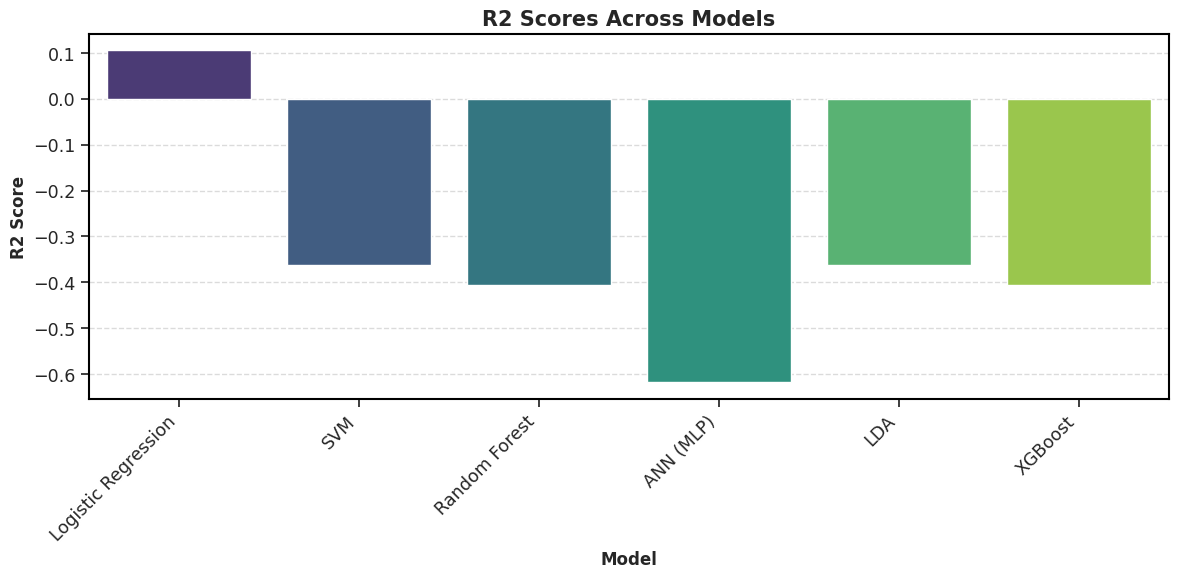

In [ ]:
# Plotting R2 values
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Value', hue='Model', data=metrics_df[metrics_df['Metric'] == 'R2'], palette='viridis', legend=False) # Add hue and set legend=False to address FutureWarning
plt.title('R2 Scores Across Models', fontsize=15, fontweight='bold') # Consistent title font size
plt.xlabel('Model', fontsize=12, fontweight='bold') # Consistent label font size
plt.ylabel('R2 Score', fontsize=12, fontweight='bold') # Consistent label font size
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Black border around plot
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('black')

plt.tight_layout()
plt.show()

## RMSE Values Across Models

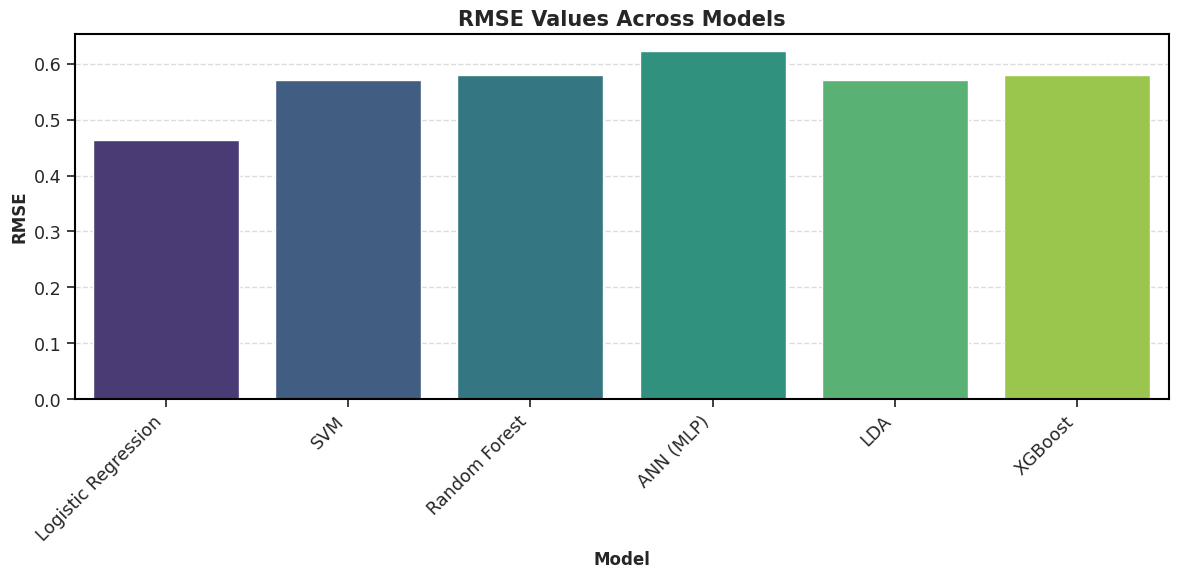

In [ ]:
# Plotting RMSE values
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Value', hue='Model', data=metrics_df[metrics_df['Metric'] == 'RMSE'], palette='viridis', legend=False) # Add hue and set legend=False to address FutureWarning
plt.title('RMSE Values Across Models', fontsize=15, fontweight='bold') # Consistent title font size
plt.xlabel('Model', fontsize=12, fontweight='bold') # Consistent label font size
plt.ylabel('RMSE', fontsize=12, fontweight='bold') # Consistent label font size
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Black border around plot
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('black')

plt.tight_layout()
plt.show()




## MAE Values Across Models

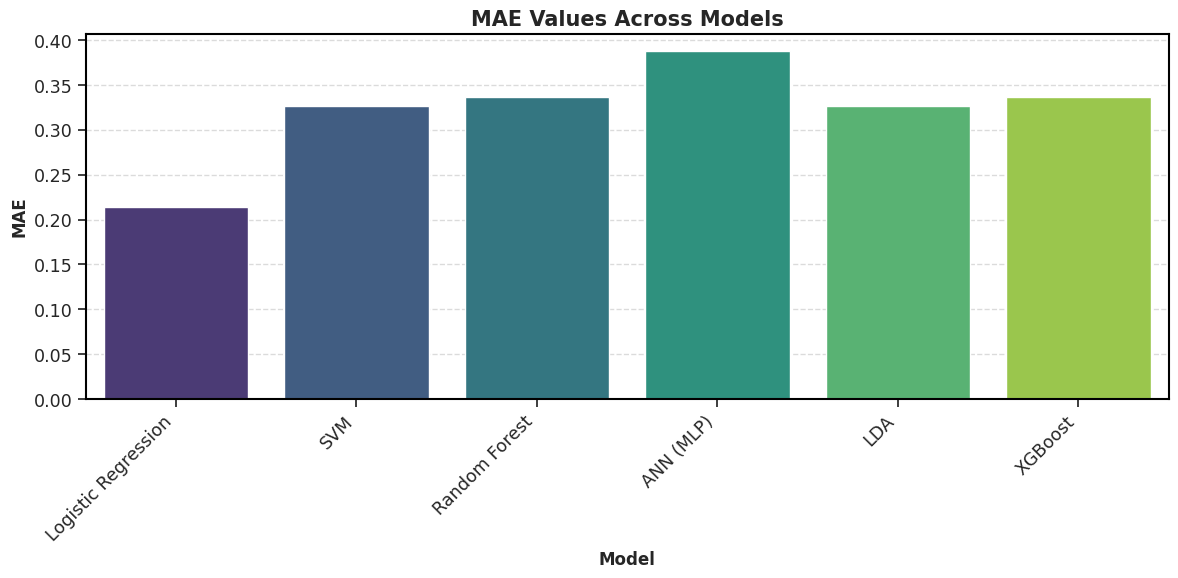

In [ ]:
# Plotting MAE values
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Value', hue='Model', data=metrics_df[metrics_df['Metric'] == 'MAE'], palette='viridis', legend=False) # Add hue and set legend=False to address FutureWarning
plt.title('MAE Values Across Models', fontsize=15, fontweight='bold') # Consistent title font size
plt.xlabel('Model', fontsize=12, fontweight='bold') # Consistent label font size
plt.ylabel('MAE', fontsize=12, fontweight='bold') # Consistent label font size
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Black border around plot
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('black')

plt.tight_layout()
plt.show()

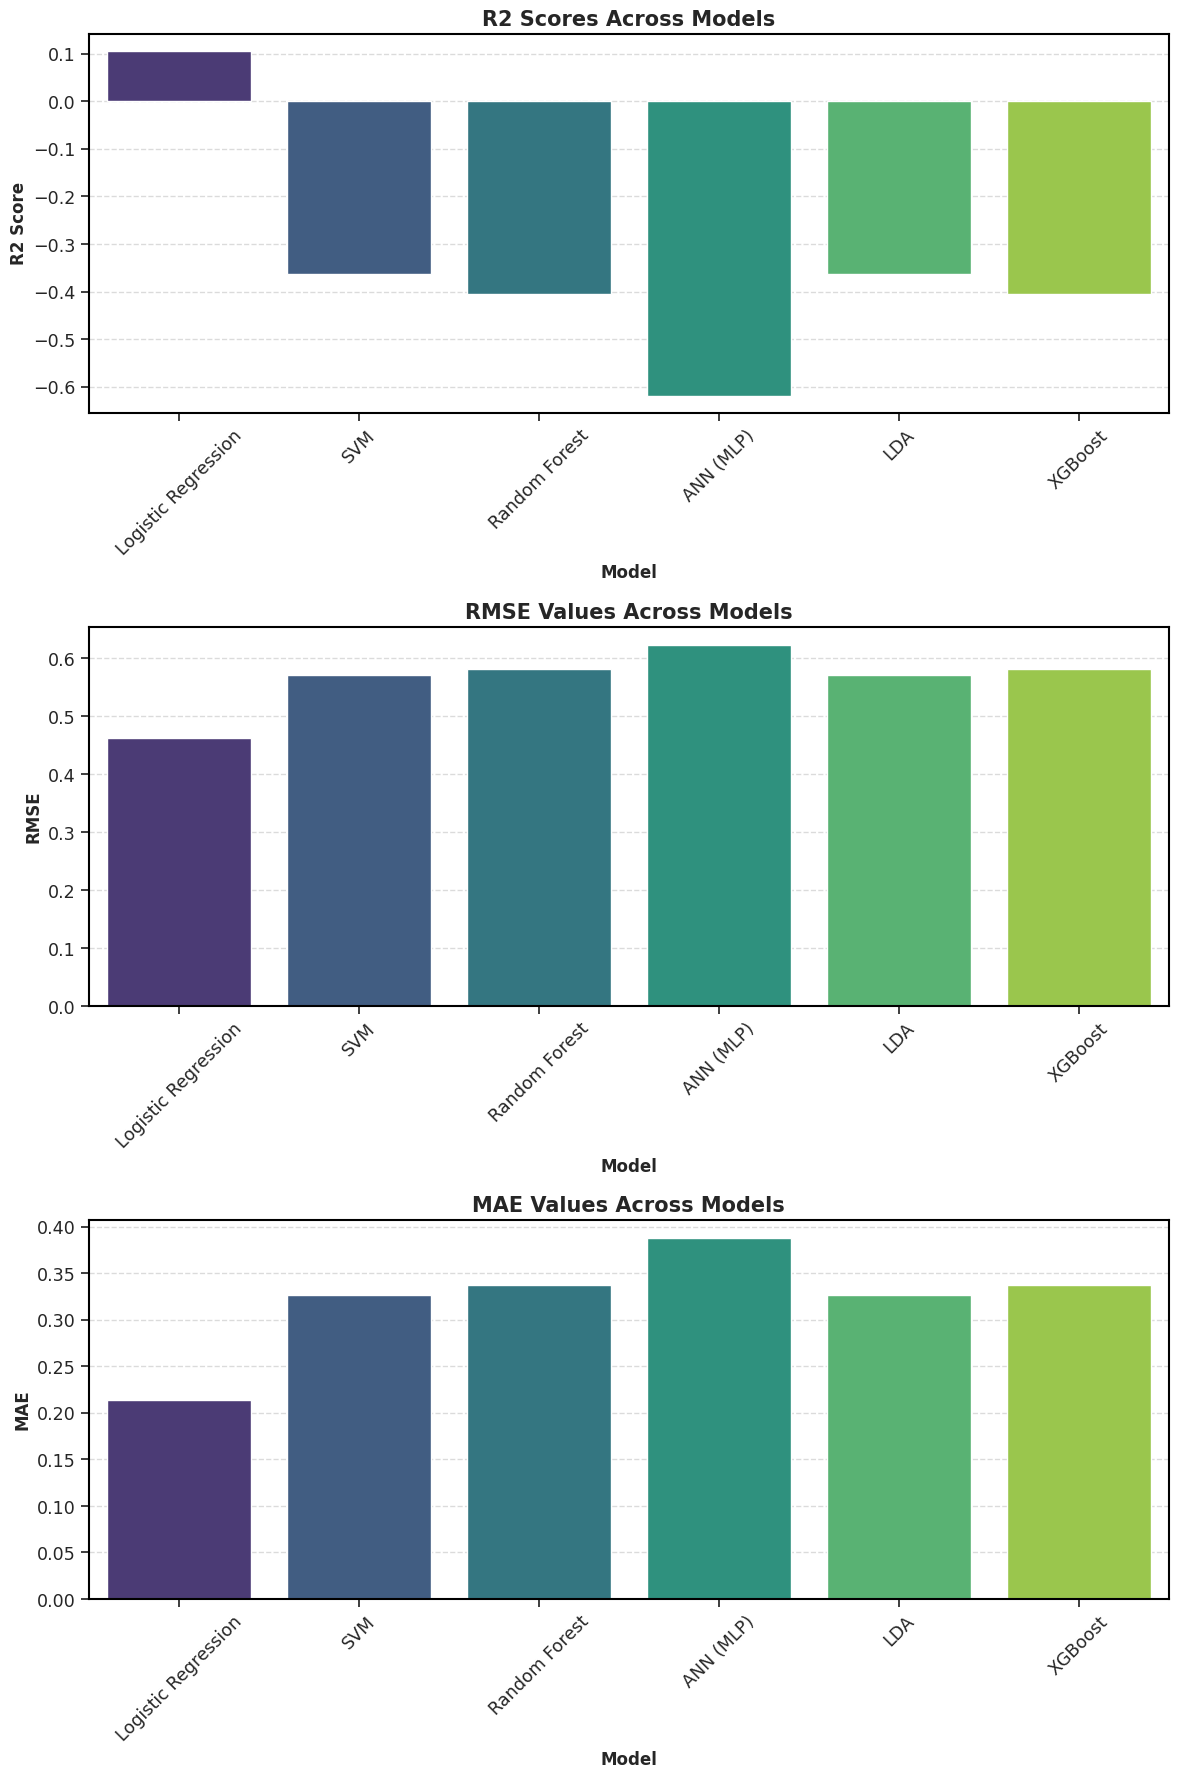

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Ensure y_test_for_metrics and y_pred_XXX are available.
# Re-establishing y_test_for_metrics as it might not be in the current execution context
X_for_metrics_split = df_top_degs[top_10_degs]
le_for_metrics_split = LabelEncoder()
y_for_metrics_split = le_for_metrics_split.fit_transform(df_top_degs['Label'])
_, _, _, y_test_for_metrics = train_test_split(X_for_metrics_split, y_for_metrics_split, test_size=0.3, random_state=42, stratify=y_for_metrics_split)

metrics_data = []

# Calculate metrics for Logistic Regression
r2_lr = r2_score(y_test_for_metrics, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_for_metrics, y_pred_lr))
mae_lr = mean_absolute_error(y_test_for_metrics, y_pred_lr)
metrics_data.append({'Model': 'Logistic Regression', 'Metric': 'R2', 'Value': r2_lr})
metrics_data.append({'Model': 'Logistic Regression', 'Metric': 'RMSE', 'Value': rmse_lr})
metrics_data.append({'Model': 'Logistic Regression', 'Metric': 'MAE', 'Value': mae_lr})

# Calculate metrics for SVM
r2_svm = r2_score(y_test_for_metrics, y_pred_svm)
rmse_svm = np.sqrt(mean_squared_error(y_test_for_metrics, y_pred_svm))
mae_svm = mean_absolute_error(y_test_for_metrics, y_pred_svm)
metrics_data.append({'Model': 'SVM', 'Metric': 'R2', 'Value': r2_svm})
metrics_data.append({'Model': 'SVM', 'Metric': 'RMSE', 'Value': rmse_svm})
metrics_data.append({'Model': 'SVM', 'Metric': 'MAE', 'Value': mae_svm})

# Calculate metrics for Random Forest
r2_rf = r2_score(y_test_for_metrics, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_for_metrics, y_pred_rf))
mae_rf = mean_absolute_error(y_test_for_metrics, y_pred_rf)
metrics_data.append({'Model': 'Random Forest', 'Metric': 'R2', 'Value': r2_rf})
metrics_data.append({'Model': 'Random Forest', 'Metric': 'RMSE', 'Value': rmse_rf})
metrics_data.append({'Model': 'Random Forest', 'Metric': 'MAE', 'Value': mae_rf})

# Calculate metrics for ANN (MLP)
r2_mlp = r2_score(y_test_for_metrics, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test_for_metrics, y_pred_mlp))
mae_mlp = mean_absolute_error(y_test_for_metrics, y_pred_mlp)
metrics_data.append({'Model': 'ANN (MLP)', 'Metric': 'R2', 'Value': r2_mlp})
metrics_data.append({'Model': 'ANN (MLP)', 'Metric': 'RMSE', 'Value': rmse_mlp})
metrics_data.append({'Model': 'ANN (MLP)', 'Metric': 'MAE', 'Value': mae_mlp})

# Calculate metrics for LDA
r2_lda = r2_score(y_test_for_metrics, y_pred_lda)
rmse_lda = np.sqrt(mean_squared_error(y_test_for_metrics, y_pred_lda))
mae_lda = mean_absolute_error(y_test_for_metrics, y_pred_lda)
metrics_data.append({'Model': 'LDA', 'Metric': 'R2', 'Value': r2_lda})
metrics_data.append({'Model': 'LDA', 'Metric': 'RMSE', 'Value': rmse_lda})
metrics_data.append({'Model': 'LDA', 'Metric': 'MAE', 'Value': mae_lda})

# Calculate metrics for XGBoost
r2_xgb = r2_score(y_test_for_metrics, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_for_metrics, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test_for_metrics, y_pred_xgb)
metrics_data.append({'Model': 'XGBoost', 'Metric': 'R2', 'Value': r2_xgb})
metrics_data.append({'Model': 'XGBoost', 'Metric': 'RMSE', 'Value': rmse_xgb})
metrics_data.append({'Model': 'XGBoost', 'Metric': 'MAE', 'Value': mae_xgb})

metrics_df = pd.DataFrame(metrics_data)


# Define the metrics and their corresponding titles and y-labels
metrics_to_plot = ['R2', 'RMSE', 'MAE']
titles = ['R2 Scores Across Models', 'RMSE Values Across Models', 'MAE Values Across Models']
y_labels = ['R2 Score', 'RMSE', 'MAE']

# Create a figure with 3 subplots (3 rows, 1 column)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 18))

# Iterate through each metric and create a subplot
for i, metric_type in enumerate(metrics_to_plot):
    ax = axes[i]
    sns.barplot(x='Model', y='Value', hue='Model', data=metrics_df[metrics_df['Metric'] == metric_type],
                palette='viridis', legend=False, ax=ax)

    ax.set_title(titles[i], fontsize=15, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax.set_ylabel(y_labels[i], fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Black border around plot
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_color('black')

plt.tight_layout()
plt.show()

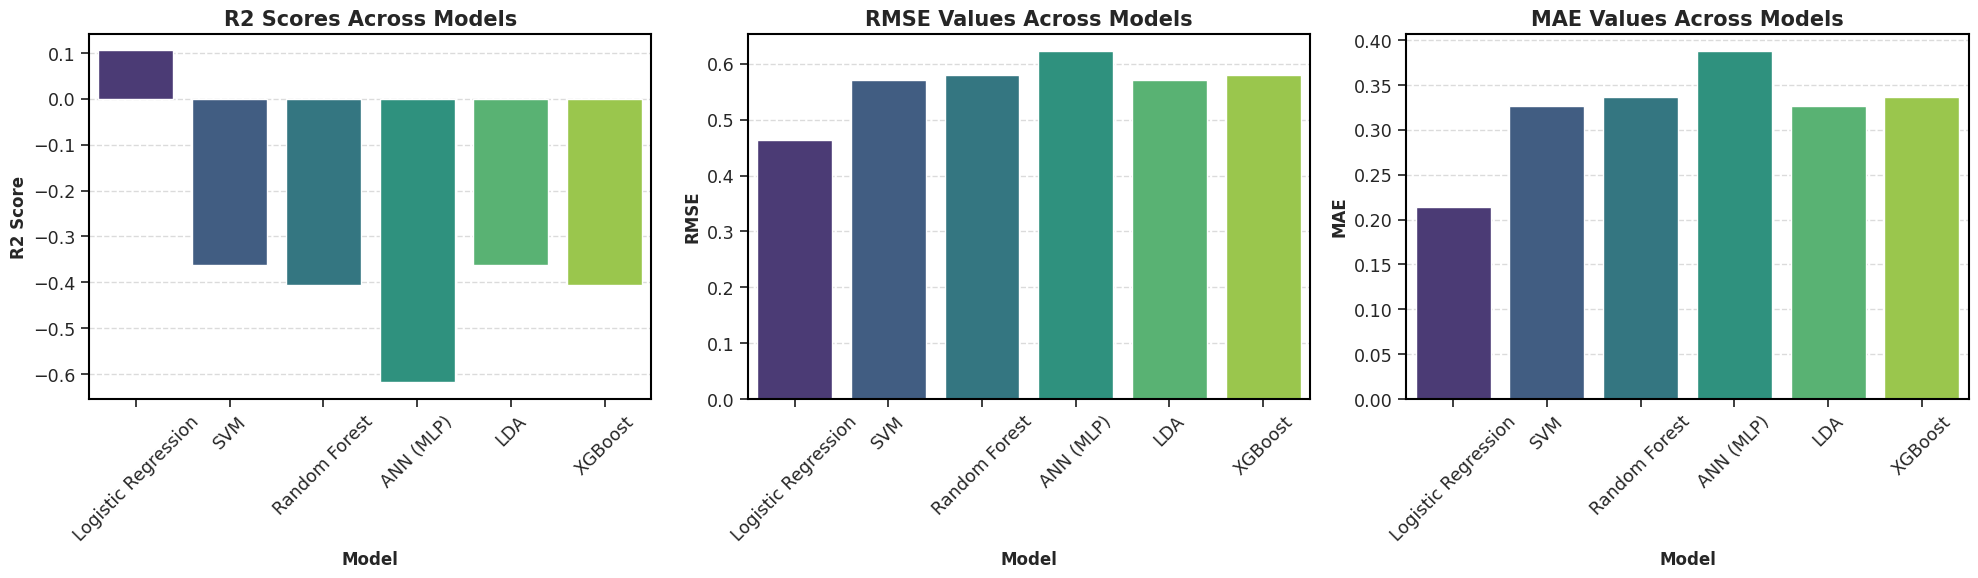

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Ensure y_test_for_metrics and y_pred_XXX are available.
# Re-establishing y_test_for_metrics as it might not be in the current execution context
X_for_metrics_split = df_top_degs[top_10_degs]
le_for_metrics_split = LabelEncoder()
y_for_metrics_split = le_for_metrics_split.fit_transform(df_top_degs['Label'])
_, _, _, y_test_for_metrics = train_test_split(X_for_metrics_split, y_for_metrics_split, test_size=0.3, random_state=42, stratify=y_for_metrics_split)

metrics_data = []

# Calculate metrics for Logistic Regression
r2_lr = r2_score(y_test_for_metrics, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_for_metrics, y_pred_lr))
mae_lr = mean_absolute_error(y_test_for_metrics, y_pred_lr)
metrics_data.append({'Model': 'Logistic Regression', 'Metric': 'R2', 'Value': r2_lr})
metrics_data.append({'Model': 'Logistic Regression', 'Metric': 'RMSE', 'Value': rmse_lr})
metrics_data.append({'Model': 'Logistic Regression', 'Metric': 'MAE', 'Value': mae_lr})

# Calculate metrics for SVM
r2_svm = r2_score(y_test_for_metrics, y_pred_svm)
rmse_svm = np.sqrt(mean_squared_error(y_test_for_metrics, y_pred_svm))
mae_svm = mean_absolute_error(y_test_for_metrics, y_pred_svm)
metrics_data.append({'Model': 'SVM', 'Metric': 'R2', 'Value': r2_svm})
metrics_data.append({'Model': 'SVM', 'Metric': 'RMSE', 'Value': rmse_svm})
metrics_data.append({'Model': 'SVM', 'Metric': 'MAE', 'Value': mae_svm})

# Calculate metrics for Random Forest
r2_rf = r2_score(y_test_for_metrics, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_for_metrics, y_pred_rf))
mae_rf = mean_absolute_error(y_test_for_metrics, y_pred_rf)
metrics_data.append({'Model': 'Random Forest', 'Metric': 'R2', 'Value': r2_rf})
metrics_data.append({'Model': 'Random Forest', 'Metric': 'RMSE', 'Value': rmse_rf})
metrics_data.append({'Model': 'Random Forest', 'Metric': 'MAE', 'Value': mae_rf})

# Calculate metrics for ANN (MLP)
r2_mlp = r2_score(y_test_for_metrics, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test_for_metrics, y_pred_mlp))
mae_mlp = mean_absolute_error(y_test_for_metrics, y_pred_mlp)
metrics_data.append({'Model': 'ANN (MLP)', 'Metric': 'R2', 'Value': r2_mlp})
metrics_data.append({'Model': 'ANN (MLP)', 'Metric': 'RMSE', 'Value': rmse_mlp})
metrics_data.append({'Model': 'ANN (MLP)', 'Metric': 'MAE', 'Value': mae_mlp})

# Calculate metrics for LDA
r2_lda = r2_score(y_test_for_metrics, y_pred_lda)
rmse_lda = np.sqrt(mean_squared_error(y_test_for_metrics, y_pred_lda))
mae_lda = mean_absolute_error(y_test_for_metrics, y_pred_lda)
metrics_data.append({'Model': 'LDA', 'Metric': 'R2', 'Value': r2_lda})
metrics_data.append({'Model': 'LDA', 'Metric': 'RMSE', 'Value': rmse_lda})
metrics_data.append({'Model': 'LDA', 'Metric': 'MAE', 'Value': mae_lda})

# Calculate metrics for XGBoost
r2_xgb = r2_score(y_test_for_metrics, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_for_metrics, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test_for_metrics, y_pred_xgb)
metrics_data.append({'Model': 'XGBoost', 'Metric': 'R2', 'Value': r2_xgb})
metrics_data.append({'Model': 'XGBoost', 'Metric': 'RMSE', 'Value': rmse_xgb})
metrics_data.append({'Model': 'XGBoost', 'Metric': 'MAE', 'Value': mae_xgb})

metrics_df = pd.DataFrame(metrics_data)


# Define the metrics and their corresponding titles and y-labels
metrics_to_plot = ['R2', 'RMSE', 'MAE']
titles = ['R2 Scores Across Models', 'RMSE Values Across Models', 'MAE Values Across Models']
y_labels = ['R2 Score', 'RMSE', 'MAE']

# Create a figure with 3 subplots (1 row, 3 columns) for horizontal layout
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6)) # Adjusted figsize for horizontal layout

# Iterate through each metric and create a subplot
for i, metric_type in enumerate(metrics_to_plot):
    ax = axes[i]
    sns.barplot(x='Model', y='Value', hue='Model', data=metrics_df[metrics_df['Metric'] == metric_type],
                palette='viridis', legend=False, ax=ax)

    ax.set_title(titles[i], fontsize=15, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax.set_ylabel(y_labels[i], fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Black border around plot
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_color('black')

plt.tight_layout()
plt.show()

### Model Performance Comparison - Graph 1

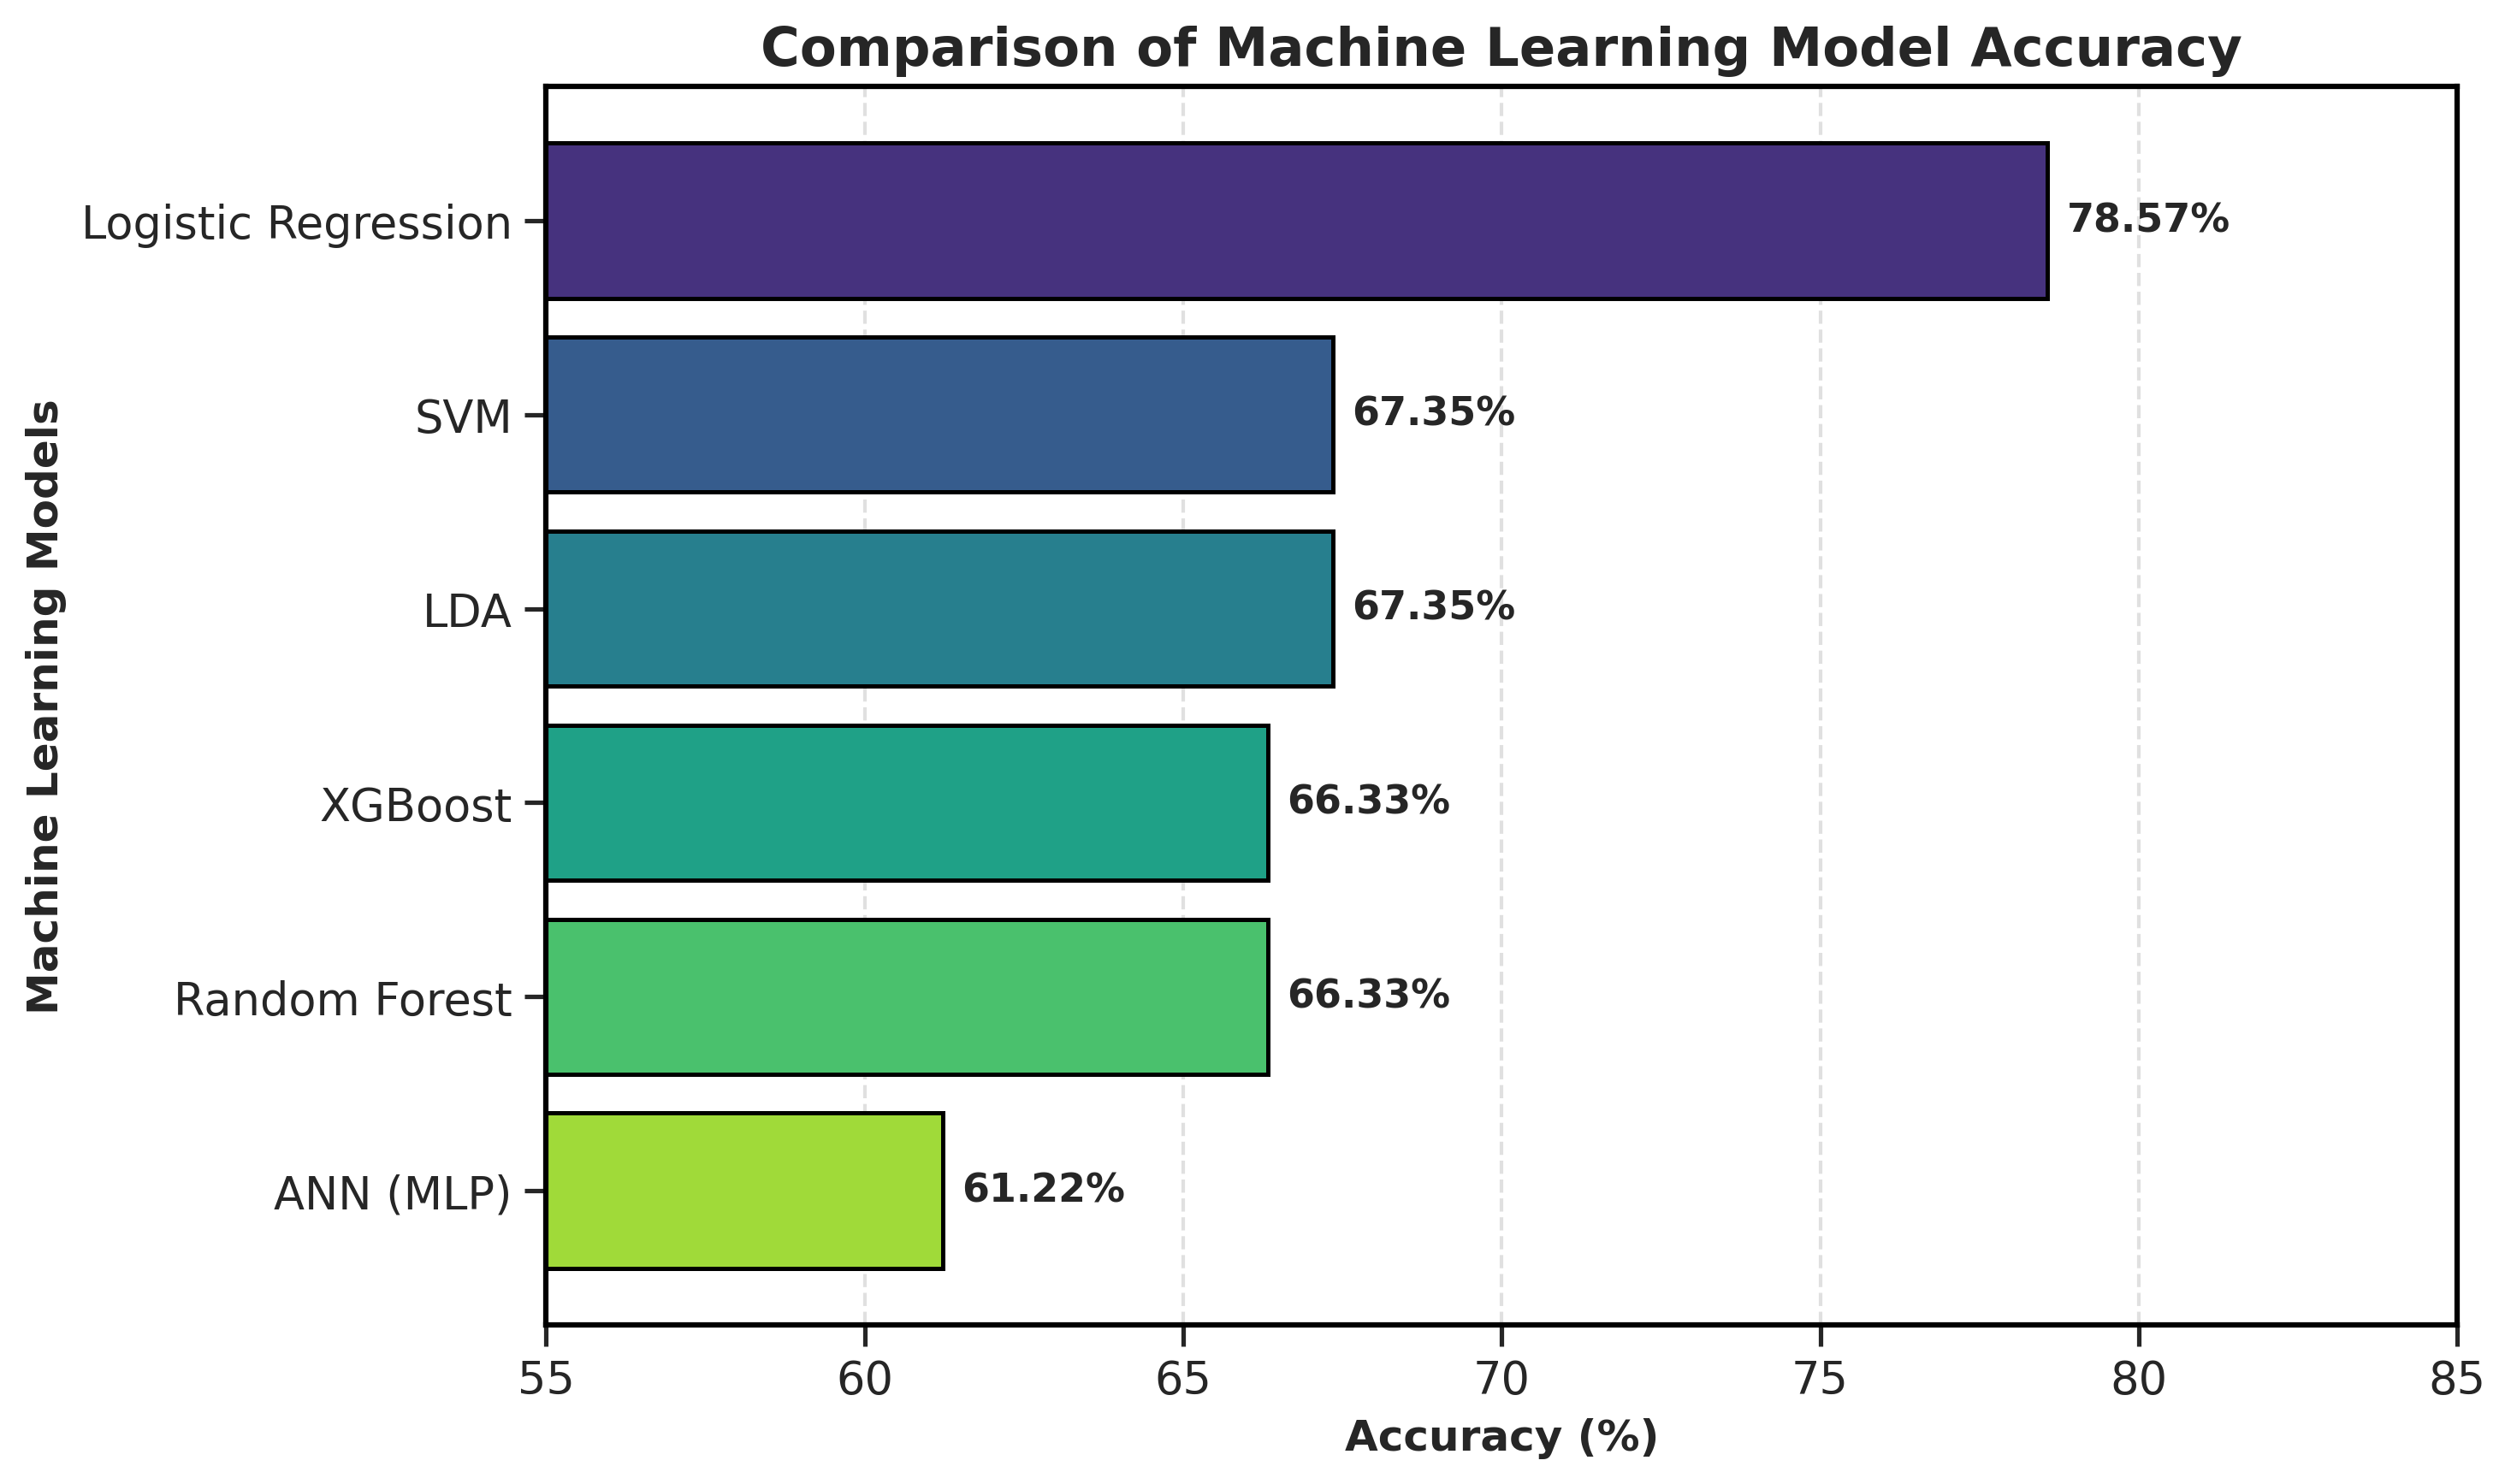

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Publication-quality style
sns.set_theme(style="ticks", font_scale=1.15)

# Model names
models = [
    'Logistic Regression',
    'SVM',
    'LDA',
    'XGBoost',
    'Random Forest',
    'ANN (MLP)'
]

# Accuracy values
accuracy = [78.57, 67.35, 67.35, 66.33, 66.33, 61.22]

# Viridis colors
colors = sns.color_palette("viridis", len(models))

# Create figure
plt.figure(figsize=(10, 6), dpi=300)

bars = plt.barh(
    models,
    accuracy,
    color=colors,
    edgecolor='black',
    linewidth=1.2
)

# Logistic Regression at top
plt.gca().invert_yaxis()

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}%',
        va='center',
        ha='left',
        fontsize=11, # Already consistent
        fontweight='bold'
    )

# Labels and title
plt.xlabel('Accuracy (%)', fontsize=12, fontweight='bold') # Already consistent
plt.ylabel('Machine Learning Models', fontsize=12, fontweight='bold') # Already consistent
plt.title(
    'Comparison of Machine Learning Model Accuracy',
    fontsize=15, # Already consistent
    fontweight='bold'
)

# X-axis range
plt.xlim(55, 85)

# Grid
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Black border around plot
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('black') # Already consistent

plt.tight_layout()

# Save publication-quality image
plt.savefig(
    'Accuracy_Comparison_Viridis.png',
    dpi=600,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

### Model Performance Comparison - Graph 2

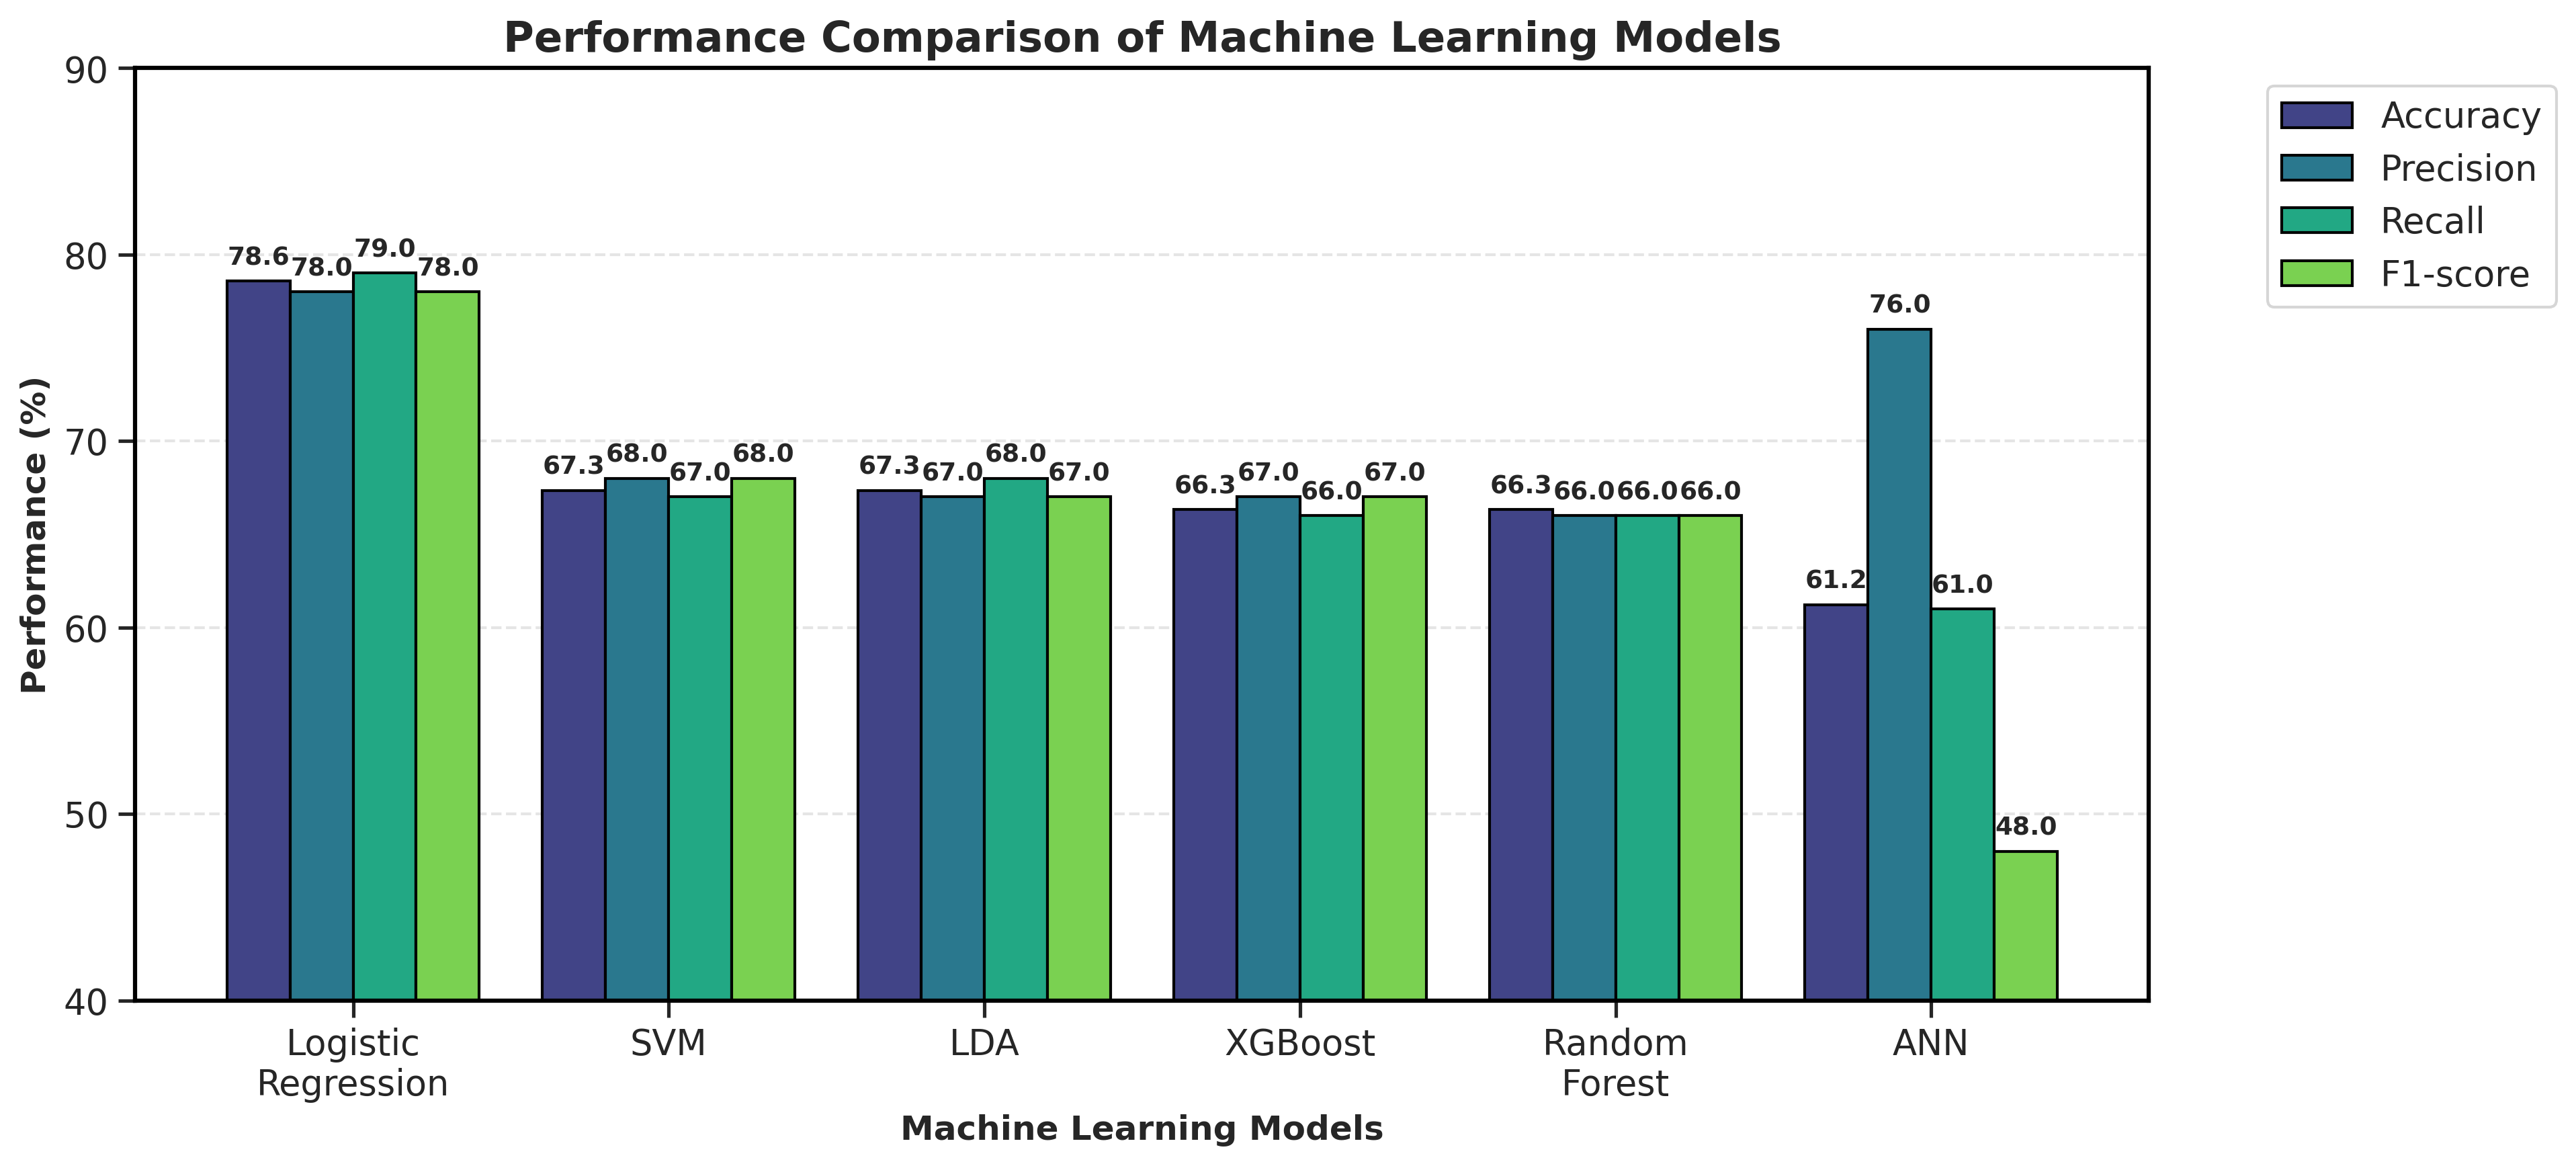

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Publication-quality style
sns.set_theme(style="ticks", font_scale=1.15)

# Models
models = [
    'Logistic\nRegression',
    'SVM',
    'LDA',
    'XGBoost',
    'Random\nForest',
    'ANN'
]

# Performance Metrics
accuracy = [78.57, 67.35, 67.35, 66.33, 66.33, 61.22]
precision = [78, 68, 67, 67, 66, 76]
recall = [79, 67, 68, 66, 66, 61]
f1 = [78, 68, 67, 67, 66, 48]

x = np.arange(len(models))
width = 0.2

# Viridis palette
colors = sns.color_palette("viridis", 4)

fig, ax = plt.subplots(figsize=(13,6), dpi=300)

bars1 = ax.bar(x-1.5*width, accuracy, width,
               label='Accuracy',
               color=colors[0],
               edgecolor='black',
               linewidth=1)

bars2 = ax.bar(x-0.5*width, precision, width,
               label='Precision',
               color=colors[1],
               edgecolor='black',
               linewidth=1)

bars3 = ax.bar(x+0.5*width, recall, width,
               label='Recall',
               color=colors[2],
               edgecolor='black',
               linewidth=1)

bars4 = ax.bar(x+1.5*width, f1, width,
               label='F1-score',
               color=colors[3],
               edgecolor='black',
               linewidth=1)

# -------- Value Labels --------
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.6,
            f'{height:.1f}',
            ha='center',
            va='bottom',
            fontsize=9, # Already consistent
            fontweight='bold'
        )

# Labels
ax.set_xticks(x)
ax.set_xticklabels(models)

ax.set_ylabel('Performance (%)', fontsize=12, fontweight='bold') # Already consistent
ax.set_xlabel('Machine Learning Models', fontsize=12, fontweight='bold') # Already consistent

ax.set_title(
    'Performance Comparison of Machine Learning Models',
    fontsize=15, # Already consistent
    fontweight='bold'
)

ax.set_ylim(40,90)

# Grid
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Legend - Adjusted location to avoid overlap
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), frameon=True) # Moved legend outside the plot area

# Black Border
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('black') # Already consistent

plt.tight_layout() # This might need to be called after setting bbox_to_anchor for legend to adjust spacing

plt.savefig(
    "Performance_Comparison_Viridis.png",
    dpi=600,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()